In [ ]:
from pathlib import Path
import numpy as np

import hbn_pl.io as io
import hbn_pl.preprocess as preprocess
import hbn_pl.plot as plot
import hbn_pl.peaks as peaks

In [2]:
DATA_DIR = Path("C://Users/ech77/OneDrive - University of Cambridge/Data Jan 2026/Large PL study, 0T")
FILE_NAME = '2026 January 23 14_00_21 Sample7_uncapped_500uW_grating150_exposure20_emitter 59.spe'
spe_path = DATA_DIR / FILE_NAME
wavelength, frames = io.load_spe(spe_path)

Performing background subtraction...
Successfully subtracted background.


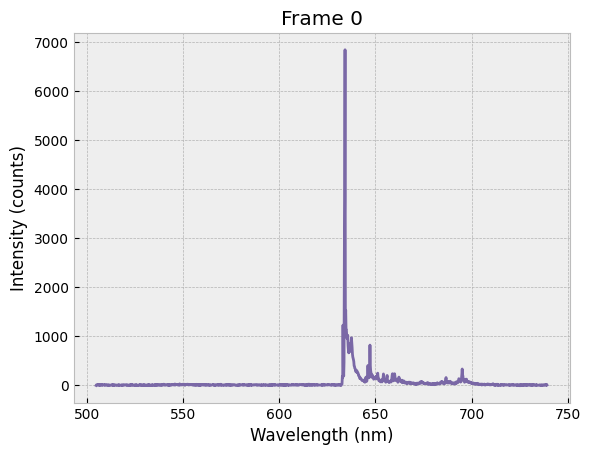

[<Figure size 640x480 with 1 Axes>]

In [3]:
# Background subtraction
frames = preprocess.background_subtract(frames, bg_slice=(1, 50))
plot.plot_frames(frames, wavelength)

In [4]:
# Cosmic ray removal
cosmic_frames, cosmic_location = preprocess.detect_cosmic_frames(frames, wavelength,
prominence_threshold=0.05, fwhm_threshold=1.9, n_peaks=3, z_thresh=100, half_width=5, noise_width=30)
plot.plot_cosmic_frames(frames, wavelength, cosmic_location)
frames_cleaned, cosmic_figs = preprocess.remove_cosmic_rays(frames, wavelength, cosmic_frames, cosmic_location, sigma=1.5, half_width = 5)

Detecting cosmic ray frames...
Only one frame detected — skipping cosmic ray detection.
Removing cosmic rays from 0 frames: []


In [5]:
# Bad frame removal
drop_fraction = 0.6
bad_frames = preprocess.detect_bad_frames_simple(frames, drop_fraction = drop_fraction)
frames = preprocess.remove_frames(frames, bad_frames)

Running simple bad frame detection...
Only one frame detected — skipping bad frame detection.
Removing 0 frames: []


Averaging and normalising frames into a single spectrum...
Successfully averaged and normalised frames.


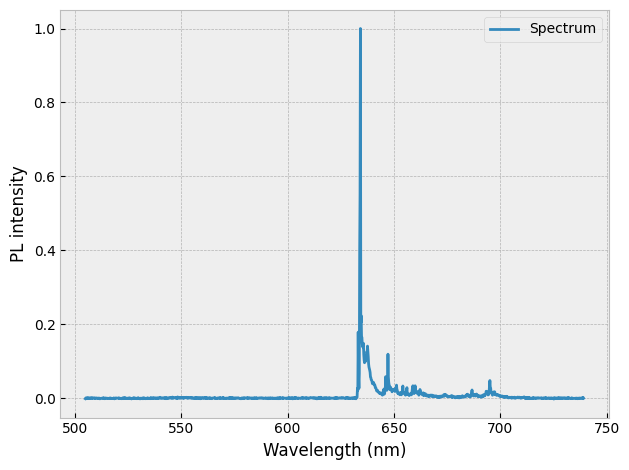

In [6]:
# Average frames and normalise
avg, avg_norm = preprocess.average_and_normalise(frames)
plot.plot_spectrum(x = wavelength, spectrum = avg_norm, x_quantity='Wavelength (nm)')

In [ ]:
# Guess the ZPL wavelength by assuming it is the tallest peak in the spectrum
max_index = np.argmax(avg_norm)
zpl_wavelength = wavelength[max_index]
print("Estimated ZPL:", zpl_wavelength)

634.2445928322562


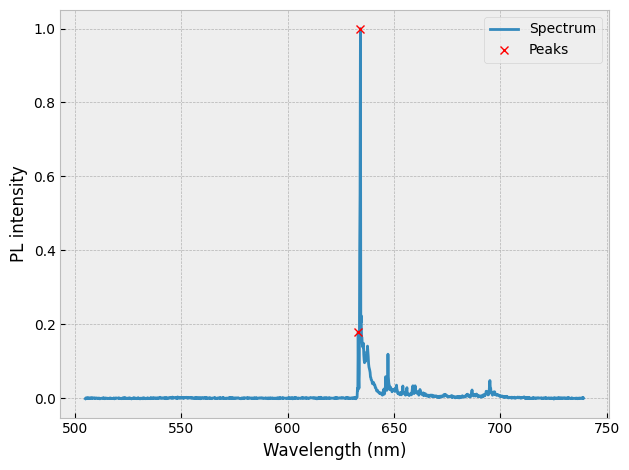

[{'location': np.float64(633.1950998075494), 'intensity': np.float64(0.1787211849379368), 'fwhm': np.float64(0.17491632474434482), 'prominence': np.float64(0.15201835819338688)}, {'location': np.float64(634.2445928322562), 'intensity': np.float64(1.0), 'fwhm': np.float64(0.34983006787354043), 'prominence': np.float64(0.9443830186711172)}]
Found ZPL-like peaks at wavelengths: [633.19509981 634.24459283]


In [8]:
# Find ZPLs centred around the guessed ZPL wavelength
peaks_found, properties = peaks.find_peaks(avg_norm, x=wavelength, center_guess=zpl_wavelength, window=5, height=0.1, width = 0.5, prominence = 0.1)
peak_params = peaks.extract_peak_parameters(wavelength, avg_norm, peaks_found, properties)
plot.plot_spectrum(x = wavelength, spectrum = avg_norm, peaks=peaks_found, x_quantity='Wavelength (nm)')
print(peak_params)
print("Found ZPL-like peaks at wavelengths:", wavelength[peaks_found])

Performing multi-ZPL correction...
Correction complete.


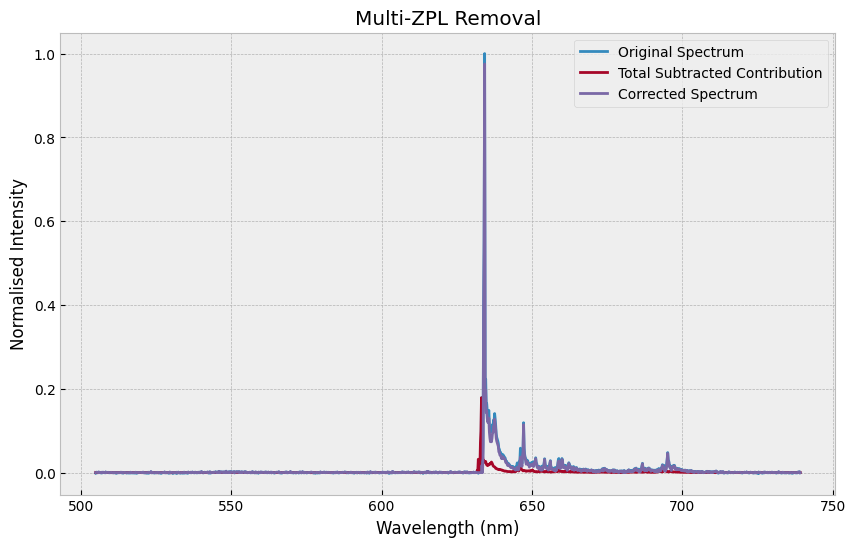

In [9]:
# If multiple ZPLs due to spectral jumping are found, attempt to remove the weaker ZPL by shifting and scaling it before subtracting from the original spectrum
# If only one ZPL, then no correction is needed and the original spectrum can be used for further analysis
if len(peak_params)>1:
    corrected = peaks.correct_spectrum(wavelength, avg_norm, peak_params, plot=True)
    corrected_spectrum = corrected / np.max(corrected) #vneed to renormalise after subtraction of multiple ZPLs
else:
    corrected_spectrum = avg_norm


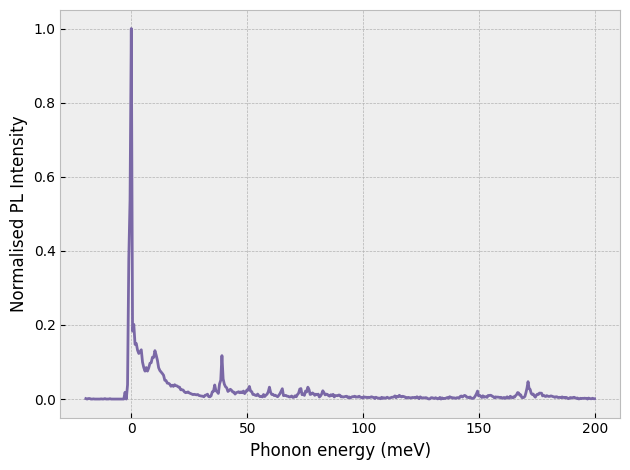

In [10]:
intensity, energy, figure = plot.plot_energy(wavelength, corrected_spectrum, zpl_wavelength)

In [11]:
io.save_preprocess_results(spe_path, intensity, energy, figure, zpl_wavelength)

Saved: C:\Users\ech77\OneDrive - University of Cambridge\Data Jan 2026\Large PL study, 0T\2026 January 23 14_00_21 Sample7_uncapped_500uW_grating150_exposure20_emitter 59_cleaned.npz
Saved: C:\Users\ech77\OneDrive - University of Cambridge\Data Jan 2026\Large PL study, 0T\2026 January 23 14_00_21 Sample7_uncapped_500uW_grating150_exposure20_emitter 59_cleaned.png
Updated: C:\Users\ech77\OneDrive - University of Cambridge\Data Jan 2026\Large PL study, 0T\ZPL_wavelengths.csv
